In [1]:
library('DiffBind')
library(ChIPseeker)
library(TxDb.Mmusculus.UCSC.mm10.knownGene)
txdb <- TxDb.Mmusculus.UCSC.mm10.knownGene
library(clusterProfiler)

Loading required package: GenomicRanges

Loading required package: stats4

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, setdiff, sort,
    table, tapply, union, unique, unsplit, which.max, which.min


Loading required package: S4Vectors


Attaching package: ‘S4Vectors’


The following object is masked from ‘package:utils’:

    findMatches


The following objects are masked from ‘package:base’:

    expand.grid, I, unname


Loading required package: IRanges

Loading required package: GenomeInfoDb

Loa

In [3]:
packageVersion('DiffBind')

[1] ‘3.12.0’

# EE vs BL

In [336]:
samples <- DataFrame(SampleID=c('BL1_1','BL1_2','BL1_3','EE1_1','EE1_2','EE1_3'))
samples$Condition <- c('BL','BL','BL','EE','EE','EE')
samples$Replicate <- c(1,2,3,1,2,3)
samples$bamReads <- c('/syn1/liangzhen/jinhua_jilab_project/result/bulkATAC/bowtie2/BL1_1_sorted.bam',
                     '/syn1/liangzhen/jinhua_jilab_project/result/bulkATAC/bowtie2/BL1_2_sorted.bam',
                     '/syn1/liangzhen/jinhua_jilab_project/result/bulkATAC/bowtie2/BL1_3_sorted.bam',
                      '/syn1/liangzhen/jinhua_jilab_project/result/bulkATAC/bowtie2/EE1_1_sorted.bam',
                     '/syn1/liangzhen/jinhua_jilab_project/result/bulkATAC/bowtie2/EE1_2_sorted.bam',
                     '/syn1/liangzhen/jinhua_jilab_project/result/bulkATAC/bowtie2/EE1_3_sorted.bam')
samples$Peaks <- c('/syn1/liangzhen/jinhua_jilab_project/result/bulkATAC/macs2/BL1_1/BL1_1_peaks.xls',
                  '/syn1/liangzhen/jinhua_jilab_project/result/bulkATAC/macs2/BL1_2/BL1_2_peaks.xls',
                  '/syn1/liangzhen/jinhua_jilab_project/result/bulkATAC/macs2/BL1_3/BL1_3_peaks.xls',
                  '/syn1/liangzhen/jinhua_jilab_project/result/bulkATAC/macs2/EE1_1/EE1_1_peaks.xls',
                  '/syn1/liangzhen/jinhua_jilab_project/result/bulkATAC/macs2/EE1_2/EE1_2_peaks.xls',
                  '/syn1/liangzhen/jinhua_jilab_project/result/bulkATAC/macs2/EE1_3/EE1_3_peaks.xls')
samples$PeakCaller <- c('macs','macs','macs','macs','macs','macs')
samples

DataFrame with 6 rows and 6 columns
     SampleID   Condition Replicate               bamReads
  <character> <character> <numeric>            <character>
1       BL1_1          BL         1 /syn1/liangzhen/jinh..
2       BL1_2          BL         2 /syn1/liangzhen/jinh..
3       BL1_3          BL         3 /syn1/liangzhen/jinh..
4       EE1_1          EE         1 /syn1/liangzhen/jinh..
5       EE1_2          EE         2 /syn1/liangzhen/jinh..
6       EE1_3          EE         3 /syn1/liangzhen/jinh..
                   Peaks  PeakCaller
             <character> <character>
1 /syn1/liangzhen/jinh..        macs
2 /syn1/liangzhen/jinh..        macs
3 /syn1/liangzhen/jinh..        macs
4 /syn1/liangzhen/jinh..        macs
5 /syn1/liangzhen/jinh..        macs
6 /syn1/liangzhen/jinh..        macs

In [337]:
samples

DataFrame with 6 rows and 6 columns
     SampleID   Condition Replicate               bamReads
  <character> <character> <numeric>            <character>
1       BL1_1          BL         1 /syn1/liangzhen/jinh..
2       BL1_2          BL         2 /syn1/liangzhen/jinh..
3       BL1_3          BL         3 /syn1/liangzhen/jinh..
4       EE1_1          EE         1 /syn1/liangzhen/jinh..
5       EE1_2          EE         2 /syn1/liangzhen/jinh..
6       EE1_3          EE         3 /syn1/liangzhen/jinh..
                   Peaks  PeakCaller
             <character> <character>
1 /syn1/liangzhen/jinh..        macs
2 /syn1/liangzhen/jinh..        macs
3 /syn1/liangzhen/jinh..        macs
4 /syn1/liangzhen/jinh..        macs
5 /syn1/liangzhen/jinh..        macs
6 /syn1/liangzhen/jinh..        macs

In [338]:
EE_vs_BL <- dba(sampleSheet=samples)

BL1_1   BL  1 macs

BL1_2   BL  2 macs

BL1_3   BL  3 macs

EE1_1   EE  1 macs

EE1_2   EE  2 macs

EE1_3   EE  3 macs



In [339]:
EE_vs_BL

6 Samples, 88896 sites in matrix (137228 total):
     ID Condition Replicate Intervals
1 BL1_1        BL         1     75224
2 BL1_2        BL         2     79569
3 BL1_3        BL         3     83356
4 EE1_1        EE         1     86261
5 EE1_2        EE         2     86265
6 EE1_3        EE         3     86753

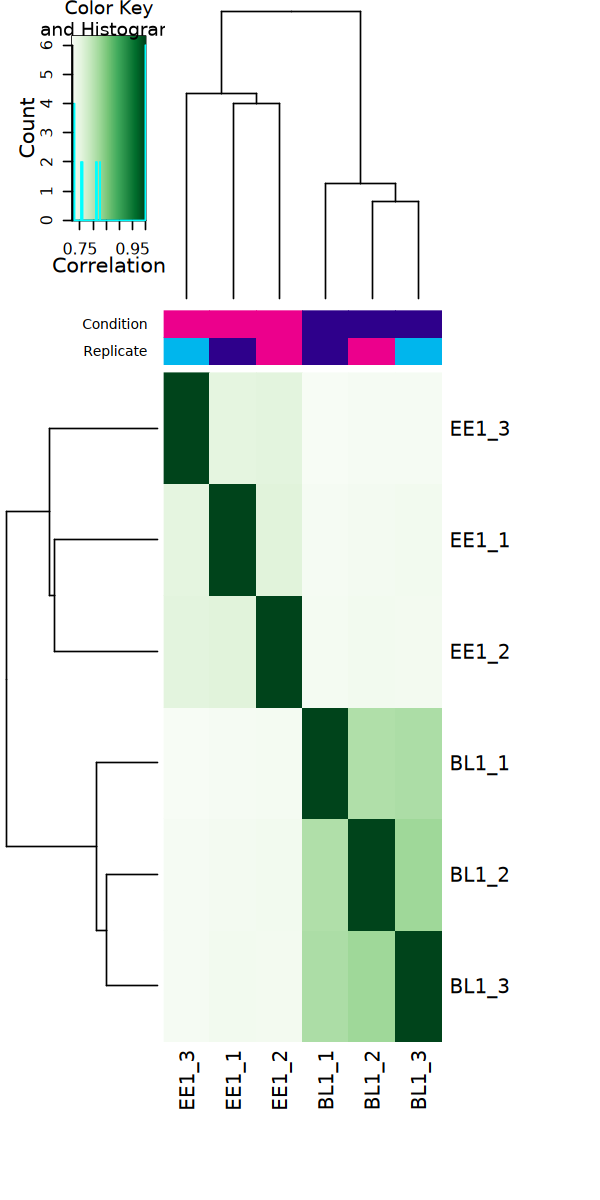

In [340]:
plot(EE_vs_BL)

In [341]:
EE_vs_BL <- dba.count(EE_vs_BL, bUseSummarizeOverlaps=TRUE)

Computing summits...

Re-centering peaks...



In [342]:
EE_vs_BL

6 Samples, 86766 sites in matrix:
     ID Condition Replicate    Reads FRiP
1 BL1_1        BL         1 30697538 0.34
2 BL1_2        BL         2 35809819 0.34
3 BL1_3        BL         3 38976683 0.34
4 EE1_1        EE         1 29056022 0.30
5 EE1_2        EE         2 29121457 0.30
6 EE1_3        EE         3 28866389 0.31

In [343]:
EE_vs_BL <- dba.normalize(EE_vs_BL)

In [344]:
EE_vs_BL.diff <- dba.contrast(EE_vs_BL,contrast=c("Condition","EE","BL"))

Computing results names...



In [345]:
EE_vs_BL.diff <- dba.analyze(EE_vs_BL.diff)

Applying Blacklist/Greylists...

Genome detected: Mmusculus.UCSC.mm10

Applying blacklist...

Removed: 1528 of 86766 intervals.

Re-normalizing...

Removed 1528 (of 86766) consensus peaks.

Analyzing...

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates



In [346]:
EE_vs_BL.diff.DB <- dba.report(EE_vs_BL.diff)

In [347]:
sum(EE_vs_BL.diff.DB$Fold>1)
sum(EE_vs_BL.diff.DB$Fold< -1)

[1] 3025

[1] 2042

In [348]:
EE_vs_BL.diff.DB

GRanges object with 31222 ranges and 6 metadata columns:
              seqnames              ranges strand |      Conc   Conc_EE
                 <Rle>           <IRanges>  <Rle> | <numeric> <numeric>
  54617           chr3 139433264-139433664      * |   7.89947   8.82235
  83175 chrUn_JH584304         59529-59929      * |  12.75843  12.47230
  59946           chr5     3355814-3356214      * |   9.48150  10.04860
  13207          chr11   79404173-79404573      * |   7.62181   8.53057
  53473           chr3 108772164-108772564      * |   8.86534   9.49403
    ...            ...                 ...    ... .       ...       ...
   5275           chr1 180175163-180175563      * |   6.19317   5.92636
  29606          chr15   85560107-85560507      * |   5.98547   6.21797
  72438           chr7 100484481-100484881      * |   6.14998   6.36715
  11321          chr11   43901284-43901684      * |   6.79770   6.59346
  20951          chr13   43068736-43069136      * |   7.62991   7.47588
       

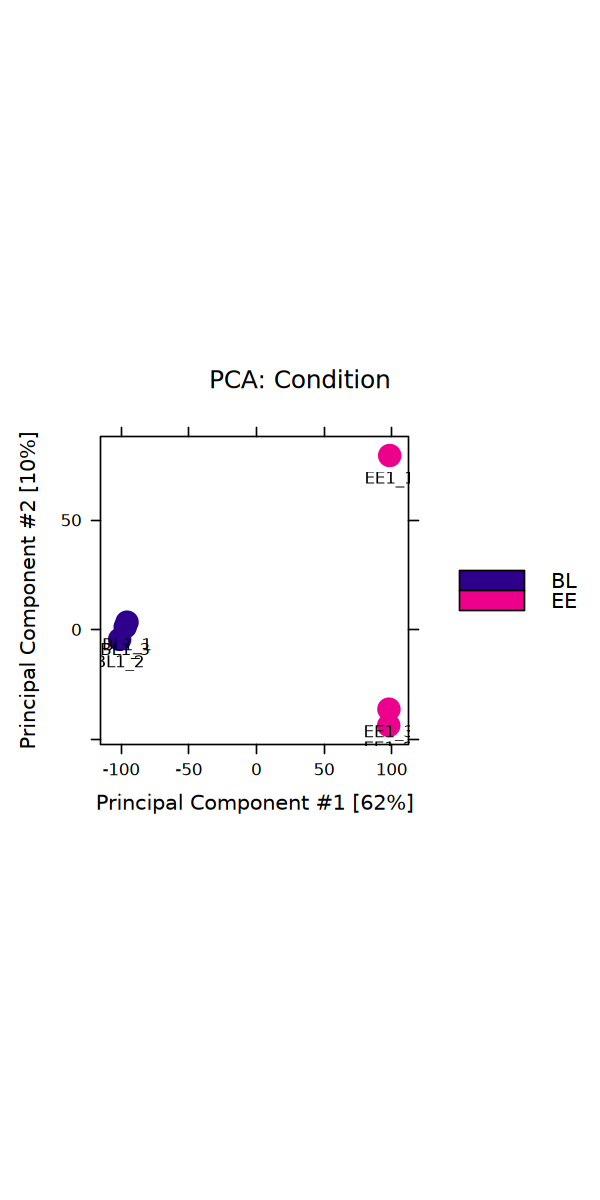

In [349]:
dba.plotPCA(EE_vs_BL.diff,DBA_CONDITION,label=DBA_ID)

In [350]:
dba.show(EE_vs_BL.diff, bContrasts=TRUE)

,Factor,Group,Samples,Group2,Samples2,DB.DESeq2
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,Condition,EE,3,BL,3,31222


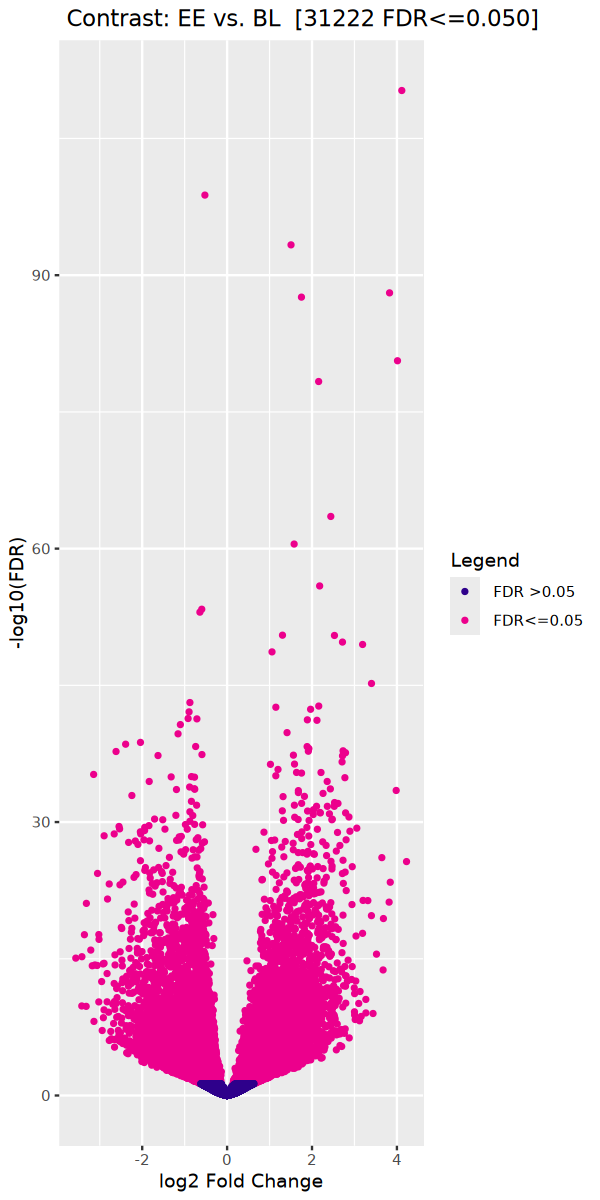

In [351]:
dba.plotVolcano(EE_vs_BL.diff)

In [352]:
as.data.frame(EE_vs_BL.diff.DB[EE_vs_BL.diff.DB$Fold > 1 & EE_vs_BL.diff.DB$FDR < 0.05,])

,seqnames,start,end,width,strand,Conc,Conc_EE,Conc_BL,Fold,p.value,FDR
,<fct>,<int>,<int>,<int>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
54617,chr3,139433264,139433664,401,*,7.899469,8.822352,4.635516,4.115088,6.415433e-116,5.468387e-111
59946,chr5,3355814,3356214,401,*,9.481498,10.048601,8.533787,1.505618,1.657100e-98,4.708263e-94
13207,chr11,79404173,79404573,401,*,7.621807,8.530575,4.593357,3.826617,4.078697e-93,8.691499e-89
53473,chr3,108772164,108772564,401,*,8.865341,9.494028,7.725607,1.751366,1.500758e-92,2.558432e-88
81770,chr9,91900951,91901351,401,*,7.505744,8.425651,4.294929,4.013754,1.718203e-85,2.440936e-81
26818,chr15,12425147,12425547,401,*,8.169921,8.883260,6.697614,2.156425,3.803840e-83,4.631882e-79
52800,chr3,98106651,98107051,401,*,7.622344,8.383625,5.909249,2.442619,2.765537e-68,2.946610e-64
16153,chr11,118043780,118044180,401,*,8.518958,9.106113,7.512360,1.578835,3.316917e-65,3.141415e-61
52803,chr3,98147699,98148099,401,*,7.800668,8.519290,6.304079,2.180187,1.456957e-60,1.241881e-56


In [353]:
write.table(as.data.frame(EE_vs_BL.diff.DB),file='/syn1/liangzhen/jinhua_jilab_project/result/bulkATAC/motif/diff_EE_vs_BL.bed',sep='\t',col.names =T,row.names = F,quote=F)

In [102]:
EE_vs_BL.diff.DB <- read.table('/syn1/liangzhen/jinhua_jilab_project/result/bulkATAC/motif/diff_EE_vs_BL.bed',sep='\t',head=T)
EE_vs_BL.diff.DB

seqnames,start,end,width,strand,Conc,Conc_EE,Conc_BL,Fold,p.value,FDR
<chr>,<int>,<int>,<int>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr3,139433264,139433664,401,*,7.899469,8.822352,4.635516,4.1150878,6.415433e-116,5.468387e-111
chrUn_JH584304,59529,59929,401,*,12.758431,12.472302,12.997096,-0.5232721,3.825072e-104,1.630208e-99
chr5,3355814,3356214,401,*,9.481498,10.048601,8.533787,1.5056182,1.657100e-98,4.708263e-94
chr11,79404173,79404573,401,*,7.621807,8.530575,4.593357,3.8266172,4.078697e-93,8.691499e-89
chr3,108772164,108772564,401,*,8.865341,9.494028,7.725607,1.7513664,1.500758e-92,2.558432e-88
chr9,91900951,91901351,401,*,7.505744,8.425651,4.294929,4.0137536,1.718203e-85,2.440936e-81
chr15,12425147,12425547,401,*,8.169921,8.883260,6.697614,2.1564247,3.803840e-83,4.631882e-79
chr3,98106651,98107051,401,*,7.622344,8.383625,5.909249,2.4426189,2.765537e-68,2.946610e-64
chr11,118043780,118044180,401,*,8.518958,9.106113,7.512360,1.5788348,3.316917e-65,3.141415e-61


In [103]:
write.table(as.data.frame(EE_vs_BL.diff.DB[EE_vs_BL.diff.DB$Fold > 1 & EE_vs_BL.diff.DB$FDR < 0.05,])[,1:3],file='/syn1/liangzhen/jinhua_jilab_project/result/bulkATAC/motif/diff_EE_vs_BL_up.bed',sep='\t',col.names = F,row.names = F,quote=F)

In [104]:
write.table(as.data.frame(EE_vs_BL.diff.DB[EE_vs_BL.diff.DB$Fold < -1 & EE_vs_BL.diff.DB$FDR < 0.05,])[,1:3],file='/syn1/liangzhen/jinhua_jilab_project/result/bulkATAC/motif/diff_EE_vs_BL_down.bed',sep='\t',col.names = F,row.names = F,quote=F)

# LE vs BL

In [312]:
samples <- DataFrame(SampleID=c('BL1_1','BL1_2','BL1_3','LE1_1','LE1_2','LE1_3'))
samples$Condition <- c('BL','BL','BL','LE','LE','LE')
samples$Replicate <- c(1,2,3,1,2,3)
samples$bamReads <- c('/syn1/liangzhen/jinhua_jilab_project/result/bulkATAC/bowtie2/BL1_1_sorted.bam',
                     '/syn1/liangzhen/jinhua_jilab_project/result/bulkATAC/bowtie2/BL1_2_sorted.bam',
                     '/syn1/liangzhen/jinhua_jilab_project/result/bulkATAC/bowtie2/BL1_3_sorted.bam',
                      '/syn1/liangzhen/jinhua_jilab_project/result/bulkATAC/bowtie2/LE1_1_sorted.bam',
                     '/syn1/liangzhen/jinhua_jilab_project/result/bulkATAC/bowtie2/LE1_2_sorted.bam',
                     '/syn1/liangzhen/jinhua_jilab_project/result/bulkATAC/bowtie2/LE1_3_sorted.bam')
samples$Peaks <- c('/syn1/liangzhen/jinhua_jilab_project/result/bulkATAC/macs2/BL1_1/BL1_1_peaks.xls',
                  '/syn1/liangzhen/jinhua_jilab_project/result/bulkATAC/macs2/BL1_2/BL1_2_peaks.xls',
                  '/syn1/liangzhen/jinhua_jilab_project/result/bulkATAC/macs2/BL1_3/BL1_3_peaks.xls',
                  '/syn1/liangzhen/jinhua_jilab_project/result/bulkATAC/macs2/LE1_1/LE1_1_peaks.xls',
                  '/syn1/liangzhen/jinhua_jilab_project/result/bulkATAC/macs2/LE1_2/LE1_2_peaks.xls',
                  '/syn1/liangzhen/jinhua_jilab_project/result/bulkATAC/macs2/LE1_3/LE1_3_peaks.xls')
samples$PeakCaller <- c('macs','macs','macs','macs','macs','macs')
samples

DataFrame with 6 rows and 6 columns
     SampleID   Condition Replicate               bamReads
  <character> <character> <numeric>            <character>
1       BL1_1          BL         1 /syn1/liangzhen/jinh..
2       BL1_2          BL         2 /syn1/liangzhen/jinh..
3       BL1_3          BL         3 /syn1/liangzhen/jinh..
4       LE1_1          LE         1 /syn1/liangzhen/jinh..
5       LE1_2          LE         2 /syn1/liangzhen/jinh..
6       LE1_3          LE         3 /syn1/liangzhen/jinh..
                   Peaks  PeakCaller
             <character> <character>
1 /syn1/liangzhen/jinh..        macs
2 /syn1/liangzhen/jinh..        macs
3 /syn1/liangzhen/jinh..        macs
4 /syn1/liangzhen/jinh..        macs
5 /syn1/liangzhen/jinh..        macs
6 /syn1/liangzhen/jinh..        macs

In [313]:
LE_vs_BL <- dba(sampleSheet=samples)

BL1_1   BL  1 macs

BL1_2   BL  2 macs

BL1_3   BL  3 macs

LE1_1   LE  1 macs

LE1_2   LE  2 macs

LE1_3   LE  3 macs



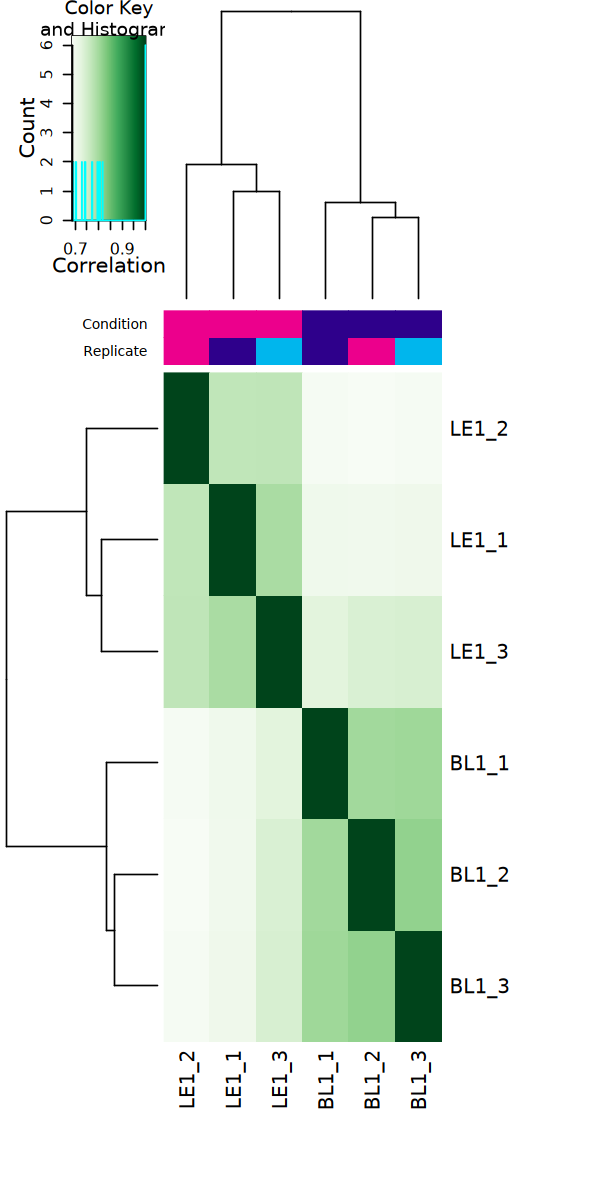

In [314]:
plot(LE_vs_BL)

In [315]:
LE_vs_BL <- dba.count(LE_vs_BL, bUseSummarizeOverlaps=TRUE)

Computing summits...

Re-centering peaks...



In [316]:
LE_vs_BL <- dba.normalize(LE_vs_BL)

In [317]:
LE_vs_BL.diff <- dba.contrast(LE_vs_BL,contrast=c("Condition","LE","BL"))

Computing results names...



In [318]:
LE_vs_BL.diff  <- dba.analyze(LE_vs_BL.diff)

Applying Blacklist/Greylists...

Genome detected: Mmusculus.UCSC.mm10

Applying blacklist...

Removed: 1569 of 86853 intervals.

Re-normalizing...

Removed 1569 (of 86853) consensus peaks.

Analyzing...

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates



In [320]:
LE_vs_BL.diff.DB <- dba.report(LE_vs_BL.diff)

In [321]:
sum(LE_vs_BL.diff.DB$Fold>1)
sum(LE_vs_BL.diff.DB$Fold< -1)

[1] 4943

[1] 4491

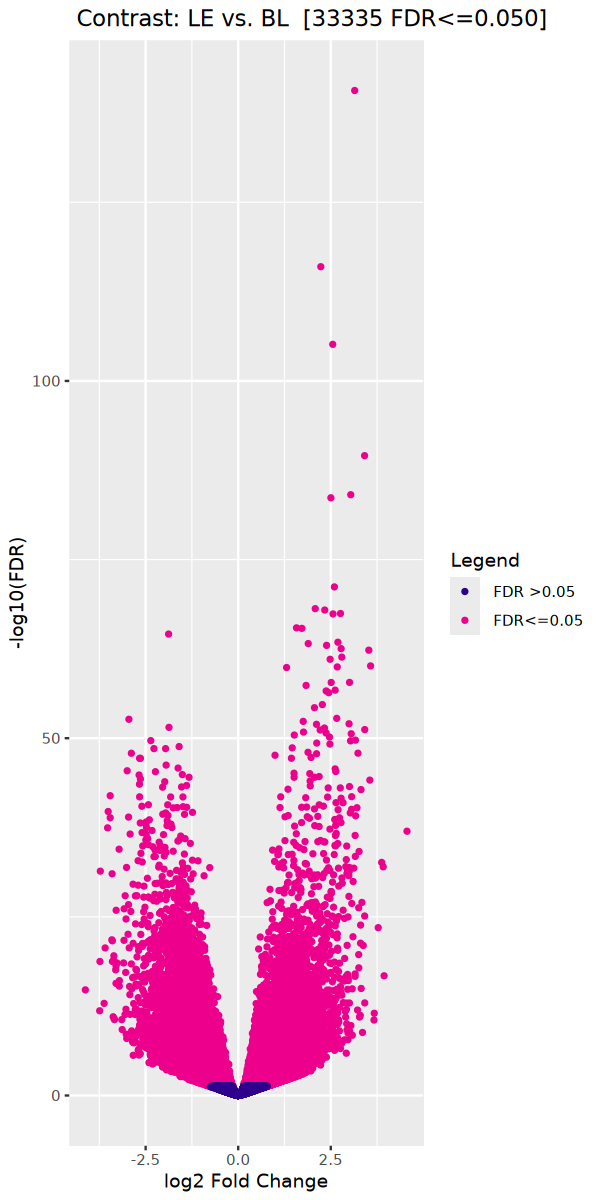

In [322]:
dba.plotVolcano(LE_vs_BL.diff)

In [327]:
write.table(as.data.frame(LE_vs_BL.diff.DB),file='/syn1/liangzhen/jinhua_jilab_project/result/bulkATAC/motif/diff_LE_vs_BL.bed',sep='\t',col.names = T,row.names = F,quote=F)

In [105]:
LE_vs_BL.diff.DB <- read.table('/syn1/liangzhen/jinhua_jilab_project/result/bulkATAC/motif/diff_LE_vs_BL.bed',sep='\t',head=T)
LE_vs_BL.diff.DB

seqnames,start,end,width,strand,Conc,Conc_LE,Conc_BL,Fold,p.value,FDR
<chr>,<int>,<int>,<int>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr3,98147679,98148079,401,*,8.797920,9.647235,6.464076,3.145517,2.673938e-146,2.280442e-141
chr3,108772154,108772554,401,*,9.407965,10.132924,7.881582,2.230283,2.431415e-121,1.036804e-116
chr15,12425135,12425535,401,*,8.685099,9.462817,6.877083,2.552677,2.659517e-110,7.560476e-106
chr14,77484986,77485386,401,*,7.882223,8.758680,5.275211,3.412680,1.345848e-94,2.869483e-90
chr11,107376264,107376664,401,*,7.906423,8.747087,5.648863,3.039054,4.921063e-89,8.393758e-85
chr3,55461596,55461996,401,*,8.297123,9.067341,6.533328,2.502468,1.594159e-88,2.265937e-84
chr3,65871212,65871612,401,*,8.001587,8.787141,6.145615,2.597644,5.491628e-76,6.690686e-72
chr5,125203796,125204196,401,*,8.417680,9.117075,7.007164,2.080171,6.899805e-73,7.355537e-69
chr3,123122620,123123020,401,*,8.072095,8.815401,6.455005,2.337070,1.207700e-72,1.144416e-68


In [106]:
write.table(as.data.frame(LE_vs_BL.diff.DB[LE_vs_BL.diff.DB$Fold > 1 & LE_vs_BL.diff.DB$FDR < 0.05,])[,1:3],file='/syn1/liangzhen/jinhua_jilab_project/result/bulkATAC/motif/diff_LE_vs_BL_up.bed',sep='\t',col.names = F,row.names = F,quote=F)

In [107]:
write.table(as.data.frame(LE_vs_BL.diff.DB[LE_vs_BL.diff.DB$Fold < -1 & LE_vs_BL.diff.DB$FDR < 0.05,])[,1:3],file='/syn1/liangzhen/jinhua_jilab_project/result/bulkATAC/motif/diff_LE_vs_BL_down.bed',sep='\t',col.names = F,row.names = F,quote=F)

# homer result

In [108]:
diff_EE_vs_BL_up <- read.csv('/syn1/liangzhen/jinhua_jilab_project/result/bulkATAC/motif/diff_EE_vs_BL_up/knownResults.txt',sep='\t',check.names = F)
diff_EE_vs_BL_up <- diff_EE_vs_BL_up[!duplicated(diff_EE_vs_BL_up$`Motif Name`),]
diff_EE_vs_BL_up$sample <- 'EE_vs_BL_up'
diff_EE_vs_BL_up <- diff_EE_vs_BL_up[,c(1,4,6,10)]
colnames(diff_EE_vs_BL_up) <- c('Motif','logPvalue','Targets_num','sample')
diff_EE_vs_BL_up

,Motif,logPvalue,Targets_num,sample
,<chr>,<dbl>,<dbl>,<chr>
1,NFkB-p65(RHD)/GM12787-p65-ChIP-Seq(GSE19485)/Homer,-384.60,465,EE_vs_BL_up
2,NFkB2-p52(RHD)/U266-NFKB2-ChIP-seq(GSE230466)/Homer,-352.50,349,EE_vs_BL_up
3,Fos(bZIP)/TSC-Fos-ChIP-Seq(GSE110950)/Homer,-208.30,1296,EE_vs_BL_up
4,AP-1(bZIP)/ThioMac-PU.1-ChIP-Seq(GSE21512)/Homer,-205.90,1394,EE_vs_BL_up
5,Atf3(bZIP)/GBM-ATF3-ChIP-Seq(GSE33912)/Homer,-205.00,1371,EE_vs_BL_up
6,BATF(bZIP)/Th17-BATF-ChIP-Seq(GSE39756)/Homer,-194.30,1323,EE_vs_BL_up
7,NFkB-p65-Rel(RHD)/ThioMac-LPS-Expression(GSE23622)/Homer,-189.90,137,EE_vs_BL_up
8,Fra1(bZIP)/BT549-Fra1-ChIP-Seq(GSE46166)/Homer,-179.00,1258,EE_vs_BL_up
9,JunB(bZIP)/DendriticCells-Junb-ChIP-Seq(GSE36099)/Homer,-161.00,1229,EE_vs_BL_up


In [109]:
diff_EE_vs_BL_down <- read.csv('/syn1/liangzhen/jinhua_jilab_project/result/bulkATAC/motif/diff_EE_vs_BL_down/knownResults.txt',sep='\t',check.names = F)
diff_EE_vs_BL_down <- diff_EE_vs_BL_down[!duplicated(diff_EE_vs_BL_down$`Motif Name`),]
diff_EE_vs_BL_down$sample <- 'EE_vs_BL_down'
diff_EE_vs_BL_down <- diff_EE_vs_BL_down[,c(1,4,6,10)]
colnames(diff_EE_vs_BL_down) <- c('Motif','logPvalue','Targets_num','sample')
diff_EE_vs_BL_down


,Motif,logPvalue,Targets_num,sample
,<chr>,<dbl>,<dbl>,<chr>
1,FOXM1(Forkhead)/MCF7-FOXM1-ChIP-Seq(GSE72977)/Homer,-406.30,550,EE_vs_BL_down
2,Nkx2.1(Homeobox)/LungAC-Nkx2.1-ChIP-Seq(GSE43252)/Homer,-372.60,970,EE_vs_BL_down
3,FOXA1(Forkhead)/MCF7-FOXA1-ChIP-Seq(GSE26831)/Homer,-347.80,555,EE_vs_BL_down
4,FOXA1(Forkhead)/LNCAP-FOXA1-ChIP-Seq(GSE27824)/Homer,-342.10,598,EE_vs_BL_down
5,Nkx2.2(Homeobox)/NPC-Nkx2.2-ChIP-Seq(GSE61673)/Homer,-325.00,699,EE_vs_BL_down
6,Nkx2.5(Homeobox)/HL1-Nkx2.5.biotin-ChIP-Seq(GSE21529)/Homer,-299.00,775,EE_vs_BL_down
7,"Fox:Ebox(Forkhead,bHLH)/Panc1-Foxa2-ChIP-Seq(GSE47459)/Homer",-226.10,474,EE_vs_BL_down
8,Bapx1(Homeobox)/VertebralCol-Bapx1-ChIP-Seq(GSE36672)/Homer,-215.30,700,EE_vs_BL_down
9,Foxa2(Forkhead)/Liver-Foxa2-ChIP-Seq(GSE25694)/Homer,-185.20,420,EE_vs_BL_down


In [110]:
diff_LE_vs_BL_up <- read.csv('/syn1/liangzhen/jinhua_jilab_project/result/bulkATAC/motif/diff_LE_vs_BL_up/knownResults.txt',sep='\t',check.names = F)
diff_LE_vs_BL_up <- diff_LE_vs_BL_up[!duplicated(diff_LE_vs_BL_up$`Motif Name`),]
diff_LE_vs_BL_up$sample <- 'LE_vs_BL_up'
diff_LE_vs_BL_up <- diff_LE_vs_BL_up[,c(1,4,6,10)]
colnames(diff_LE_vs_BL_up) <- c('Motif','logPvalue','Targets_num','sample')
diff_LE_vs_BL_up

,Motif,logPvalue,Targets_num,sample
,<chr>,<dbl>,<dbl>,<chr>
1,Fra1(bZIP)/BT549-Fra1-ChIP-Seq(GSE46166)/Homer,-360.50,2074,LE_vs_BL_up
2,Atf3(bZIP)/GBM-ATF3-ChIP-Seq(GSE33912)/Homer,-352.70,2219,LE_vs_BL_up
3,BATF(bZIP)/Th17-BATF-ChIP-Seq(GSE39756)/Homer,-341.60,2159,LE_vs_BL_up
4,Fos(bZIP)/TSC-Fos-ChIP-Seq(GSE110950)/Homer,-332.00,2116,LE_vs_BL_up
5,JunB(bZIP)/DendriticCells-Junb-ChIP-Seq(GSE36099)/Homer,-327.50,2032,LE_vs_BL_up
6,AP-1(bZIP)/ThioMac-PU.1-ChIP-Seq(GSE21512)/Homer,-326.30,2241,LE_vs_BL_up
7,Fra2(bZIP)/Striatum-Fra2-ChIP-Seq(GSE43429)/Homer,-308.70,1911,LE_vs_BL_up
8,Fosl2(bZIP)/3T3L1-Fosl2-ChIP-Seq(GSE56872)/Homer,-250.20,1580,LE_vs_BL_up
9,BORIS(Zf)/K562-CTCFL-ChIP-Seq(GSE32465)/Homer,-185.80,255,LE_vs_BL_up


In [111]:
diff_LE_vs_BL_down <- read.csv('/syn1/liangzhen/jinhua_jilab_project/result/bulkATAC/motif/diff_LE_vs_BL_down/knownResults.txt',sep='\t',check.names = F)
diff_LE_vs_BL_down <- diff_LE_vs_BL_down[!duplicated(diff_LE_vs_BL_down$`Motif Name`),]
diff_LE_vs_BL_down$sample <- 'LE_vs_BL_down'
diff_LE_vs_BL_down <- diff_LE_vs_BL_down[,c(1,4,6,10)]
colnames(diff_LE_vs_BL_down) <- c('Motif','logPvalue','Targets_num','sample')
diff_LE_vs_BL_down

,Motif,logPvalue,Targets_num,sample
,<chr>,<dbl>,<dbl>,<chr>
1,FOXA1(Forkhead)/MCF7-FOXA1-ChIP-Seq(GSE26831)/Homer,-855.50,1188,LE_vs_BL_down
2,FOXA1(Forkhead)/LNCAP-FOXA1-ChIP-Seq(GSE27824)/Homer,-832.50,1319,LE_vs_BL_down
3,FOXM1(Forkhead)/MCF7-FOXM1-ChIP-Seq(GSE72977)/Homer,-731.80,1170,LE_vs_BL_down
4,Nkx2.1(Homeobox)/LungAC-Nkx2.1-ChIP-Seq(GSE43252)/Homer,-481.10,1903,LE_vs_BL_down
5,Foxa3(Forkhead)/Liver-Foxa3-ChIP-Seq(GSE77670)/Homer,-476.30,555,LE_vs_BL_down
6,"Fox:Ebox(Forkhead,bHLH)/Panc1-Foxa2-ChIP-Seq(GSE47459)/Homer",-463.00,1041,LE_vs_BL_down
7,Foxa2(Forkhead)/Liver-Foxa2-ChIP-Seq(GSE25694)/Homer,-453.20,902,LE_vs_BL_down
8,Nkx2.5(Homeobox)/HL1-Nkx2.5.biotin-ChIP-Seq(GSE21529)/Homer,-387.90,1532,LE_vs_BL_down
9,FoxL2(Forkhead)/Ovary-FoxL2-ChIP-Seq(GSE60858)/Homer,-383.00,778,LE_vs_BL_down


In [152]:
motifs_selected

[1] "Fra1"      "Atf3"      "BATF"      "Fos"       "JunB"      "AP-1"     
 [7] "Fra2"      "Fosl2"     "BORIS"     "CTCF"      "Jun-AP1"   "NFkB2-p52"
[13] "NFkB-p65"  "REST-NRSF" "Twist2"    "FOXA1"     "FOXA1"     "FOXM1"    
[19] "Nkx2.1"    "Foxa3"     "Fox:Ebox"  "Foxa2"     "Nkx2.5"    "FoxL2"    
[25] "Nkx2.2"    "Foxo3"     "FOXK1"     "Foxf1"     "Bapx1"     "FOXP1"

In [194]:
motif_enrich <- rbind(diff_EE_vs_BL_up,diff_EE_vs_BL_down,diff_LE_vs_BL_up,diff_LE_vs_BL_down)
motif_enrich$logPvalue <- -motif_enrich$logPvalue
motif_enrich <- motif_enrich[order(motif_enrich$logPvalue,decreasing = T),]
motif_enrich$Motif <- as.character(as.data.frame(strsplit(motif_enrich$Motif,split = '/'))[1,])
motif_enrich$Motif <- gsub("\\(.*?\\)", "", motif_enrich$Motif)
motif_enrich$sample_motif <- paste0(motif_enrich$sample,'_',motif_enrich$Motif)
motif_enrich <- motif_enrich[!duplicated(motif_enrich$sample_motif),]
motifs_selected <- motif_enrich[motif_enrich$sample=='LE_vs_BL_up','Motif'][1:10]
motifs_selected <- c(motifs_selected,motif_enrich[motif_enrich$sample=='LE_vs_BL_down','Motif'][1:10])
motif_enrich <- motif_enrich[motif_enrich$Motif %in% motifs_selected,]
motif_enrich <- motif_enrich[,c(1,2,4)]
motif_enrich 

,Motif,logPvalue,sample
,<chr>,<dbl>,<chr>
1104,FOXA1,855.5,LE_vs_BL_down
3104,FOXM1,731.8,LE_vs_BL_down
477,Nkx2.1,481.1,LE_vs_BL_down
514,Foxa3,476.3,LE_vs_BL_down
614,Fox:Ebox,463.0,LE_vs_BL_down
714,Foxa2,453.2,LE_vs_BL_down
1100,FOXM1,406.3,EE_vs_BL_down
814,Nkx2.5,387.9,LE_vs_BL_down
914,FoxL2,383.0,LE_vs_BL_down


In [198]:
length(unique(motif_enrich$Motif))

[1] 20

In [199]:
library(tidyr)

In [200]:
motif_enrich.wider <- as.data.frame(pivot_wider(data = motif_enrich,
                                  id_cols = Motif,  
                                  names_from = 'sample',
                                  values_from = 'logPvalue'))
motif_enrich.wider

Motif,LE_vs_BL_down,EE_vs_BL_down,LE_vs_BL_up,EE_vs_BL_up
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
FOXA1,855.5,347.8000,0.0,0.00000
FOXM1,731.8,406.3000,0.0,0.00000
Nkx2.1,481.1,372.6000,0.0,0.00000
Foxa3,476.3,147.4000,0.0,0.00000
Fox:Ebox,463.0,226.1000,0.0,0.00000
Foxa2,453.2,185.2000,0.0,0.00000
Nkx2.5,387.9,299.0000,0.0,0.00000
FoxL2,383.0,183.2000,0.0,0.00000
Nkx2.2,377.2,325.0000,0.0,0.00000


In [201]:
df <- motif_enrich.wider
rownames(df) <- df$Motif
df <- df[,-1]
df <- df[,c('EE_vs_BL_down','LE_vs_BL_down','EE_vs_BL_up','LE_vs_BL_up')]
df

,EE_vs_BL_down,LE_vs_BL_down,EE_vs_BL_up,LE_vs_BL_up
,<dbl>,<dbl>,<dbl>,<dbl>
FOXA1,347.8000,855.5,0.00000,0.0
FOXM1,406.3000,731.8,0.00000,0.0
Nkx2.1,372.6000,481.1,0.00000,0.0
Foxa3,147.4000,476.3,0.00000,0.0
Fox:Ebox,226.1000,463.0,0.00000,0.0
Foxa2,185.2000,453.2,0.00000,0.0
Nkx2.5,299.0000,387.9,0.00000,0.0
FoxL2,183.2000,383.0,0.00000,0.0
Nkx2.2,325.0000,377.2,0.00000,0.0


In [202]:
library(ComplexHeatmap)
library(RColorBrewer)

In [231]:
my_colors <- colorRampPalette(c("#ece0da", "#e55959"))(100)
#my_colors <- colorRampPalette(rev(brewer.pal(n = 5, name = "RdBu")))(100)

In [232]:
df[df>300] <- 300

Warning message:
“The input is a data frame-like object, convert it to a matrix.”


png 
  2

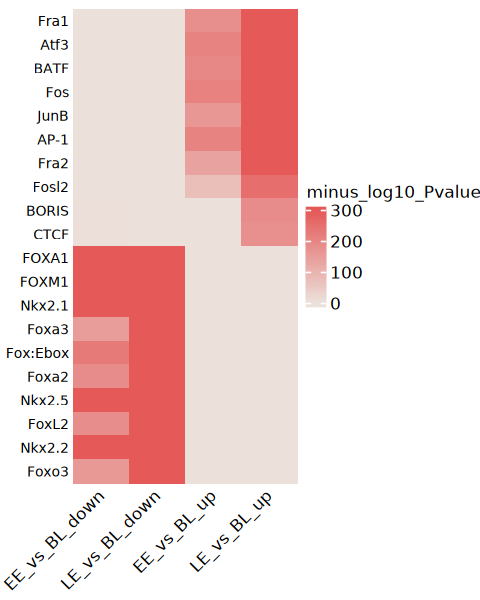

In [234]:
options(repr.plot.width=4, repr.plot.height=5)
pdf('/syn1/liangzhen/jinhua_jilab_project/result/Figures/heatmap_bulkATAC_TF_enrich.pdf',width=4,height=5)
# 使用cell_fun为每个单元格添加黑色边框
plot <- Heatmap(df[motifs_selected,c('EE_vs_BL_down','LE_vs_BL_down','EE_vs_BL_up','LE_vs_BL_up')],
        row_names_side = 'left',name = "minus_log10_Pvalue",
        cluster_rows = F, 
        cluster_columns = F,
        col = my_colors,
        # 添加单元格边框
        #cell_fun = function(j, i, x, y, width, height, fill) {
        #    grid.rect(x = x, y = y, width = width, height = height, 
        #             gp = gpar(col = "black", fill = NA, lwd = 0.5))
        #},
        # 可选：设置矩形边框的宽度
        #rect_gp = gpar(col = "black", lwd = 1),
        # 其他设置
        #na_col = "grey90",
        row_names_gp = gpar(fontsize = 8),
        column_names_gp = gpar(fontsize = 10),
        column_names_rot = 45)
print(plot)
dev.off()
print(plot)